In [3]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import sys
print(sys.executable)

c:\Users\Asus\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
env_path = Path("../../backend/.env")
load_dotenv(dotenv_path=env_path)

MONGO_URI = os.getenv("MONGO_URI")

print("Mongo URI loaded:", MONGO_URI is not None)

Mongo URI loaded: True


In [5]:
client = MongoClient(MONGO_URI)
db = client["asthmaDB"]

sensor_collection = db["sensordatas"]
profile_collection = db["medicalprofiles"]

sensor_data = list(sensor_collection.find())
profile_data = list(profile_collection.find())

print("Total sensor documents fetched:", len(sensor_data))
print("Total medical profile documents fetched:", len(profile_data))

Total sensor documents fetched: 1570
Total medical profile documents fetched: 2


In [4]:
sensor_df = pd.DataFrame(sensor_data)
profile_df = pd.DataFrame(profile_data)

print("Sensor DF shape:", sensor_df.shape)
print("Profile DF shape:", profile_df.shape)

Sensor DF shape: (846, 12)
Profile DF shape: (2, 14)


In [5]:
sensor_df.head()

,_id,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10,timestamp,__v,location
0,69cd4113a4a4330da357a57c,3.705689,10.0,8.413441,31.7,50,20,29,29,2026-04-01 16:00:19.095,0,"{'latitude': 26.1243, 'longitude': 91.76}"
1,69cd411fa4a4330da357a584,3.743311,10.0,8.080150,31.9,50,20,29,29,2026-04-01 16:00:31.052,0,"{'latitude': 24.84314758813627, 'longitude': 9..."
2,69cd412da4a4330da357a588,3.689696,10.0,8.443026,31.9,49,20,29,29,2026-04-01 16:00:45.495,0,NaN
3,69cd4139a4a4330da357a58a,3.652678,10.0,8.592427,31.9,49,19,28,28,2026-04-01 16:00:57.984,0,NaN
4,69cd4146a4a4330da357a58c,3.595344,10.0,8.867670,31.8,49,19,28,28,2026-04-01 16:01:10.134,0,NaN


In [6]:
profile_df.head()

,_id,userId,__v,age,asthma_severity,createdAt,gender,height_cm,known_triggers,last_hospitalization,rescue_inhaler_use,smoking_status,updatedAt,weight_kg
0,69d16cf977c78cdc805a2ebc,69d13e79f6e0337cfe20bade,0,21,Intermittent,2026-04-04 19:56:41.025,Female,155,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,2026-04-06 16:10:08.731,47
1,69d3da9277c78cdc805a48bd,69d3da197c8f01be5f6aaafe,0,19,Intermittent,2026-04-06 16:08:49.861,Female,164,[Smoke],Never,Rarely,Non-smoker,2026-04-06 16:08:49.861,50


In [8]:
# Convert ObjectId fields to string where present
if "_id" in sensor_df.columns:
    sensor_df["_id"] = sensor_df["_id"].astype(str)

if "_id" in profile_df.columns:
    profile_df["_id"] = profile_df["_id"].astype(str)

if "userId" in profile_df.columns:
    profile_df["userId"] = profile_df["userId"].astype(str)

print("sensor_df columns:")
print(sensor_df.columns.tolist())
print()
print("profile_df columns:")
print(profile_df.columns.tolist())

sensor_df columns:
['_id', 'co_ppm', 'o3_ppb', 'no2_ppb', 'temperature', 'humidity', 'pm1', 'pm25', 'pm10', 'timestamp', '__v', 'location']

profile_df columns:
['_id', 'userId', '__v', 'age', 'asthma_severity', 'createdAt', 'gender', 'height_cm', 'known_triggers', 'last_hospitalization', 'rescue_inhaler_use', 'smoking_status', 'updatedAt', 'weight_kg']


In [9]:
# Parse datetime columns if present
if "recordedAt" in sensor_df.columns:
    sensor_df["recordedAt"] = pd.to_datetime(sensor_df["recordedAt"], errors="coerce")

if "updatedAt" in profile_df.columns:
    profile_df["updatedAt"] = pd.to_datetime(profile_df["updatedAt"], errors="coerce")

if "createdAt" in profile_df.columns:
    profile_df["createdAt"] = pd.to_datetime(profile_df["createdAt"], errors="coerce")

In [10]:
# Keep latest medical profile per user
if "userId" in profile_df.columns:
    if "updatedAt" in profile_df.columns:
        profile_df = profile_df.sort_values("updatedAt").drop_duplicates(subset=["userId"], keep="last")
    elif "createdAt" in profile_df.columns:
        profile_df = profile_df.sort_values("createdAt").drop_duplicates(subset=["userId"], keep="last")
    else:
        profile_df = profile_df.drop_duplicates(subset=["userId"], keep="last")

print("Profiles after dedup:", len(profile_df))

Profiles after dedup: 2


In [11]:
required_sensor_cols = [
    "co_ppm",
    "o3_ppb",
    "no2_ppb",
    "temperature",
    "humidity",
    "pm1",
    "pm25",
    "pm10"
]

required_profile_cols = [
    "userId",
    "age",
    "asthma_severity",
    "known_triggers",
    "last_hospitalization",
    "rescue_inhaler_use",
    "smoking_status",
    "height_cm",
    "weight_kg"
]

sensor_df = sensor_df[required_sensor_cols].copy()
profile_df = profile_df[required_profile_cols].copy()

print("Sensor rows:", len(sensor_df))
print("Profile rows:", len(profile_df))

Sensor rows: 846
Profile rows: 2


In [12]:
sensor_df.head()

,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10
0,3.705689,10.0,8.413441,31.7,50,20,29,29
1,3.743311,10.0,8.080150,31.9,50,20,29,29
2,3.689696,10.0,8.443026,31.9,49,20,29,29
3,3.652678,10.0,8.592427,31.9,49,19,28,28
4,3.595344,10.0,8.867670,31.8,49,19,28,28


In [13]:
profile_df.head()

,userId,age,asthma_severity,known_triggers,last_hospitalization,rescue_inhaler_use,smoking_status,height_cm,weight_kg
1,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
0,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47


In [14]:
# Clean sensor numeric columns
for col in required_sensor_cols:
    sensor_df[col] = pd.to_numeric(sensor_df[col], errors="coerce")

sensor_df.dropna(subset=required_sensor_cols, inplace=True)

# Clean profile numeric columns
for col in ["age", "height_cm", "weight_kg"]:
    profile_df[col] = pd.to_numeric(profile_df[col], errors="coerce")

profile_df.dropna(subset=["age", "asthma_severity", "last_hospitalization", "rescue_inhaler_use", "smoking_status"], inplace=True)

print("Sensor rows after cleaning:", len(sensor_df))
print("Profile rows after cleaning:", len(profile_df))

Sensor rows after cleaning: 846
Profile rows after cleaning: 2


In [15]:
def safe_trigger_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        return [x]
    return []

profile_df["known_triggers"] = profile_df["known_triggers"].apply(safe_trigger_list)
profile_df.head()

,userId,age,asthma_severity,known_triggers,last_hospitalization,rescue_inhaler_use,smoking_status,height_cm,weight_kg
1,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
0,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47


In [16]:
# Cross join: every sensor row with every user profile
sensor_df["_tmp_key"] = 1
profile_df["_tmp_key"] = 1

df = sensor_df.merge(profile_df, on="_tmp_key").drop(columns=["_tmp_key"])

print("Personalized training rows after cross join:", len(df))
df.head()

Personalized training rows after cross join: 1692


,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10,userId,age,asthma_severity,known_triggers,last_hospitalization,rescue_inhaler_use,smoking_status,height_cm,weight_kg
0,3.705689,10.0,8.413441,31.7,50,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
1,3.705689,10.0,8.413441,31.7,50,20,29,29,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47
2,3.743311,10.0,8.080150,31.9,50,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
3,3.743311,10.0,8.080150,31.9,50,20,29,29,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47
4,3.689696,10.0,8.443026,31.9,49,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50


In [17]:
# Cross join: every sensor row with every user profile
sensor_df["_tmp_key"] = 1
profile_df["_tmp_key"] = 1

df = sensor_df.merge(profile_df, on="_tmp_key").drop(columns=["_tmp_key"])

print("Personalized training rows after cross join:", len(df))
df.head()

Personalized training rows after cross join: 1692


,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10,userId,age,asthma_severity,known_triggers,last_hospitalization,rescue_inhaler_use,smoking_status,height_cm,weight_kg
0,3.705689,10.0,8.413441,31.7,50,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
1,3.705689,10.0,8.413441,31.7,50,20,29,29,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47
2,3.743311,10.0,8.080150,31.9,50,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50
3,3.743311,10.0,8.080150,31.9,50,20,29,29,69d13e79f6e0337cfe20bade,21,Intermittent,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",Never,Rarely,Non-smoker,155,47
4,3.689696,10.0,8.443026,31.9,49,20,29,29,69d3da197c8f01be5f6aaafe,19,Intermittent,[Smoke],Never,Rarely,Non-smoker,164,50


In [19]:
severity_map = {
    "Intermittent": 0.20,
    "Mild Persistent": 0.40,
    "Moderate Persistent": 0.70,
    "Severe Persistent": 1.00
}

hospitalization_map = {
    "Never": 0.00,
    "More than 1 year ago": 0.30,
    "Within last year": 0.70,
    "Within last 3 months": 1.00
}

inhaler_map = {
    "Rarely": 0.20,
    "Sometimes": 0.50,
    "Often": 0.80,
    "Daily": 1.00
}

smoking_map = {
    "Non-smoker": 0.00,
    "Passive smoker": 0.40,
    "Former smoker": 0.30,
    "Current smoker": 1.00
}

In [20]:
df["severity_score"] = df["asthma_severity"].map(severity_map).fillna(0.0)
df["hospitalization_score"] = df["last_hospitalization"].map(hospitalization_map).fillna(0.0)
df["inhaler_score"] = df["rescue_inhaler_use"].map(inhaler_map).fillna(0.0)
df["smoking_score"] = df["smoking_status"].map(smoking_map).fillna(0.0)

df[[
    "asthma_severity",
    "severity_score",
    "last_hospitalization",
    "hospitalization_score",
    "rescue_inhaler_use",
    "inhaler_score",
    "smoking_status",
    "smoking_score"
]].head()

,asthma_severity,severity_score,last_hospitalization,hospitalization_score,rescue_inhaler_use,inhaler_score,smoking_status,smoking_score
0,Intermittent,0.2,Never,0.0,Rarely,0.2,Non-smoker,0.0
1,Intermittent,0.2,Never,0.0,Rarely,0.2,Non-smoker,0.0
2,Intermittent,0.2,Never,0.0,Rarely,0.2,Non-smoker,0.0
3,Intermittent,0.2,Never,0.0,Rarely,0.2,Non-smoker,0.0
4,Intermittent,0.2,Never,0.0,Rarely,0.2,Non-smoker,0.0


In [21]:
def compute_bmi(weight_kg, height_cm):
    if pd.isna(weight_kg) or pd.isna(height_cm) or height_cm == 0:
        return 0.0
    return weight_kg / ((height_cm / 100.0) ** 2)

df["bmi"] = df.apply(lambda row: compute_bmi(row["weight_kg"], row["height_cm"]), axis=1)

df[["weight_kg", "height_cm", "bmi"]].head()

,weight_kg,height_cm,bmi
0,50,164,18.590125
1,47,155,19.562955
2,50,164,18.590125
3,47,155,19.562955
4,50,164,18.590125


In [22]:
def encode_trigger_flags(trigger_list):
    trigger_list = [str(t).lower() for t in trigger_list]

    return pd.Series({
        "trigger_dust": int(any("dust" in t for t in trigger_list)),
        "trigger_pollen": int(any(("pollen" in t) or ("seasonal" in t) for t in trigger_list)),
        "trigger_smoke": int(any("smoke" in t for t in trigger_list)),
        "trigger_humidity": int(any(("humidity" in t) or ("damp" in t) for t in trigger_list)),
        "trigger_cold_air": int(any("cold" in t for t in trigger_list)),
        "trigger_pollution": int(any(("pollution" in t) or ("traffic" in t) for t in trigger_list))
    })

trigger_flags = df["known_triggers"].apply(encode_trigger_flags)
df = pd.concat([df, trigger_flags], axis=1)

df[[
    "known_triggers",
    "trigger_dust",
    "trigger_pollen",
    "trigger_smoke",
    "trigger_humidity",
    "trigger_cold_air",
    "trigger_pollution"
]].head()

,known_triggers,trigger_dust,trigger_pollen,trigger_smoke,trigger_humidity,trigger_cold_air,trigger_pollution
0,[Smoke],0,0,1,0,0,0
1,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",1,1,0,0,0,0
2,[Smoke],0,0,1,0,0,0
3,"[Dust & Dust Mites, Pollen / Seasonal Allergies]",1,1,0,0,0,0
4,[Smoke],0,0,1,0,0,0


In [23]:
def label_pm1(x):
    if x > 35:
        return 2
    elif x >= 10:
        return 1
    else:
        return 0

def label_pm25(x):
    if x > 35:
        return 2
    elif x >= 16:
        return 1
    else:
        return 0

def label_pm10(x):
    if x > 100:
        return 2
    elif x >= 46:
        return 1
    else:
        return 0

def label_no2(x):
    if x > 51:
        return 2
    elif x >= 21:
        return 1
    else:
        return 0

def label_o3(x):
    if x > 61:
        return 2
    elif x >= 36:
        return 1
    else:
        return 0

def label_co(x):
    if x > 6:
        return 2
    elif x >= 2.1:
        return 1
    else:
        return 0

def label_temperature(x):
    if x <= 15 or x >= 35:
        return 2
    elif (15 < x < 20) or (30 < x < 35):
        return 1
    else:
        return 0

def label_humidity(x):
    if x > 60:
        return 2
    elif x < 30 or (50 < x <= 60):
        return 1
    else:
        return 0

In [24]:
df["pm1_label"] = df["pm1"].apply(label_pm1)
df["pm25_label"] = df["pm25"].apply(label_pm25)
df["pm10_label"] = df["pm10"].apply(label_pm10)
df["no2_label"] = df["no2_ppb"].apply(label_no2)
df["o3_label"] = df["o3_ppb"].apply(label_o3)
df["co_label"] = df["co_ppm"].apply(label_co)
df["temperature_label"] = df["temperature"].apply(label_temperature)
df["humidity_label"] = df["humidity"].apply(label_humidity)

df[[
    "pm1_label",
    "pm25_label",
    "pm10_label",
    "no2_label",
    "o3_label",
    "co_label",
    "temperature_label",
    "humidity_label"
]].head()

,pm1_label,pm25_label,pm10_label,no2_label,o3_label,co_label,temperature_label,humidity_label
0,1,1,0,0,0,1,1,0
1,1,1,0,0,0,1,1,0
2,1,1,0,0,0,1,1,0
3,1,1,0,0,0,1,1,0
4,1,1,0,0,0,1,1,0


In [25]:
df["environment_label_sum"] = df[
    [
        "pm1_label",
        "pm25_label",
        "pm10_label",
        "no2_label",
        "o3_label",
        "co_label",
        "temperature_label",
        "humidity_label"
    ]
].sum(axis=1)

df[[
    "environment_label_sum"
]].head()

,environment_label_sum
0,4
1,4
2,4
3,4
4,4


In [26]:
def medical_label_score(row):
    score = (
        row["severity_score"] * 3.0 +
        row["hospitalization_score"] * 2.0 +
        row["inhaler_score"] * 2.0 +
        row["smoking_score"] * 1.5 +
        row["trigger_dust"] * 0.5 +
        row["trigger_pollen"] * 0.5 +
        row["trigger_smoke"] * 0.5 +
        row["trigger_humidity"] * 0.5 +
        row["trigger_cold_air"] * 0.5 +
        row["trigger_pollution"] * 0.5
    )
    return score

df["medical_label_score"] = df.apply(medical_label_score, axis=1)

df[[
    "severity_score",
    "hospitalization_score",
    "inhaler_score",
    "smoking_score",
    "medical_label_score"
]].head()

,severity_score,hospitalization_score,inhaler_score,smoking_score,medical_label_score
0,0.2,0.0,0.2,0.0,1.5
1,0.2,0.0,0.2,0.0,2.0
2,0.2,0.0,0.2,0.0,1.5
3,0.2,0.0,0.2,0.0,2.0
4,0.2,0.0,0.2,0.0,1.5


In [27]:
def medical_risk_band(score):
    if score >= 4.5:
        return 2
    elif score >= 2.0:
        return 1
    else:
        return 0

df["medical_risk_band"] = df["medical_label_score"].apply(medical_risk_band)

print(df["medical_risk_band"].value_counts())

medical_risk_band
0    846
1    846
Name: count, dtype: int64


In [28]:
df["personalized_label_sum"] = df["environment_label_sum"] + (df["medical_risk_band"] * 2)

def final_personalized_risk_label(total):
    if total >= 8:
        return 2   # High
    elif total >= 4:
        return 1   # Moderate
    else:
        return 0   # Low

df["risk_label"] = df["personalized_label_sum"].apply(final_personalized_risk_label)

df[[
    "environment_label_sum",
    "medical_risk_band",
    "personalized_label_sum",
    "risk_label"
]].head()

,environment_label_sum,medical_risk_band,personalized_label_sum,risk_label
0,4,0,4,1
1,4,1,6,1
2,4,0,4,1
3,4,1,6,1
4,4,0,4,1


In [29]:
print(df["risk_label"].value_counts())
print()
print(df["risk_label"].value_counts(normalize=True) * 100)

risk_label
1    1213
2     441
0      38
Name: count, dtype: int64

risk_label
1    71.690307
2    26.063830
0     2.245863
Name: proportion, dtype: float64


In [30]:
feature_cols = [
    "co_ppm",
    "o3_ppb",
    "no2_ppb",
    "temperature",
    "humidity",
    "pm1",
    "pm25",
    "pm10",
    "age",
    "bmi",
    "severity_score",
    "hospitalization_score",
    "inhaler_score",
    "smoking_score",
    "trigger_dust",
    "trigger_pollen",
    "trigger_smoke",
    "trigger_humidity",
    "trigger_cold_air",
    "trigger_pollution"
]

X = df[feature_cols].copy()
y = df["risk_label"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1692, 20)
y shape: (1692,)


In [31]:
X["co_ppm"] = X["co_ppm"].clip(upper=50)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1353
Testing samples: 339


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Personalized risk model trained successfully")

Personalized risk model trained successfully


In [34]:
y_pred = rf_model.predict(X_test)
y_pred[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9941002949852508

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.99      1.00      1.00       243
           2       1.00      0.99      0.99        88

    accuracy                           0.99       339
   macro avg       1.00      0.95      0.97       339
weighted avg       0.99      0.99      0.99       339

Confusion Matrix:
[[  7   1   0]
 [  0 243   0]
 [  0   1  87]]


In [36]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,pm10,0.168323
5,pm1,0.158085
6,pm25,0.149869
0,co_ppm,0.139964
4,humidity,0.122148
3,temperature,0.067879
2,no2_ppb,0.050365
14,trigger_dust,0.031569
9,bmi,0.031165
15,trigger_pollen,0.028924


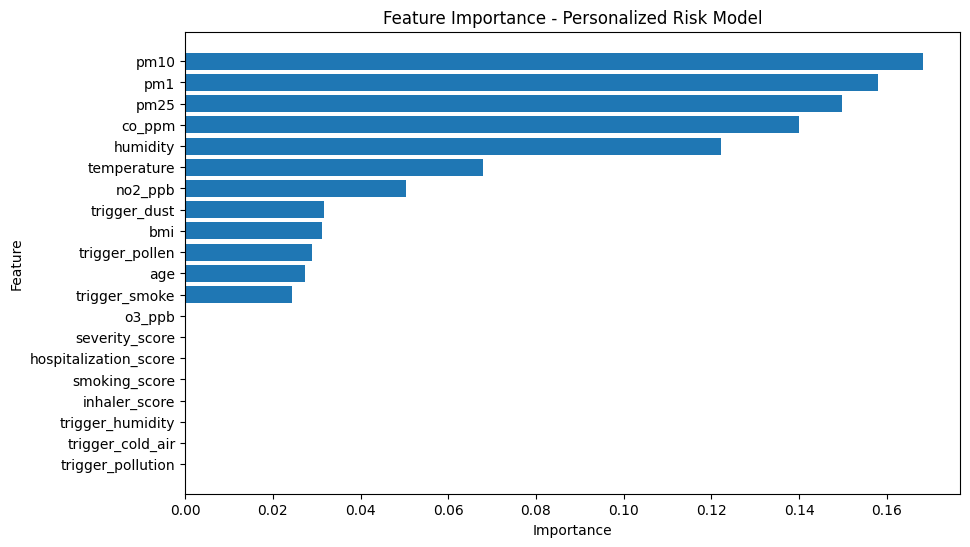

In [37]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Personalized Risk Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [38]:
os.makedirs("../models", exist_ok=True)

bundle = {
    "model": rf_model,
    "features": feature_cols,
    "label_map": {
        0: "Low",
        1: "Moderate",
        2: "High"
    }
}

joblib.dump(bundle, "../models/personalized_risk_rf_bundle.pkl")
print("Model saved to ../models/personalized_risk_rf_bundle.pkl")

Model saved to ../models/personalized_risk_rf_bundle.pkl


In [39]:
df[[
    "co_ppm",
    "o3_ppb",
    "no2_ppb",
    "temperature",
    "humidity",
    "pm1",
    "pm25",
    "pm10",
    "age",
    "asthma_severity",
    "last_hospitalization",
    "rescue_inhaler_use",
    "smoking_status",
    "environment_label_sum",
    "medical_label_score",
    "medical_risk_band",
    "personalized_label_sum",
    "risk_label"
]].head(10)

,co_ppm,o3_ppb,no2_ppb,temperature,humidity,pm1,pm25,pm10,age,asthma_severity,last_hospitalization,rescue_inhaler_use,smoking_status,environment_label_sum,medical_label_score,medical_risk_band,personalized_label_sum,risk_label
0,3.705689,10.0,8.413441,31.7,50,20,29,29,19,Intermittent,Never,Rarely,Non-smoker,4,1.5,0,4,1
1,3.705689,10.0,8.413441,31.7,50,20,29,29,21,Intermittent,Never,Rarely,Non-smoker,4,2.0,1,6,1
2,3.743311,10.0,8.080150,31.9,50,20,29,29,19,Intermittent,Never,Rarely,Non-smoker,4,1.5,0,4,1
3,3.743311,10.0,8.080150,31.9,50,20,29,29,21,Intermittent,Never,Rarely,Non-smoker,4,2.0,1,6,1
4,3.689696,10.0,8.443026,31.9,49,20,29,29,19,Intermittent,Never,Rarely,Non-smoker,4,1.5,0,4,1
5,3.689696,10.0,8.443026,31.9,49,20,29,29,21,Intermittent,Never,Rarely,Non-smoker,4,2.0,1,6,1
6,3.652678,10.0,8.592427,31.9,49,19,28,28,19,Intermittent,Never,Rarely,Non-smoker,4,1.5,0,4,1
7,3.652678,10.0,8.592427,31.9,49,19,28,28,21,Intermittent,Never,Rarely,Non-smoker,4,2.0,1,6,1
8,3.595344,10.0,8.867670,31.8,49,19,28,28,19,Intermittent,Never,Rarely,Non-smoker,4,1.5,0,4,1
9,3.595344,10.0,8.867670,31.8,49,19,28,28,21,Intermittent,Never,Rarely,Non-smoker,4,2.0,1,6,1


In [40]:
os.makedirs("../data_exports", exist_ok=True)
df.to_csv("../data_exports/personalized_risk_training_data_labeled.csv", index=False)
print("Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled.csv")

Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled.csv


In [41]:
sample = X.iloc[[0]]
pred = rf_model.predict(sample)[0]
probs = rf_model.predict_proba(sample)[0]

print("Predicted label:", {0: "Low", 1: "Moderate", 2: "High"}[pred])
print("Probabilities:", probs)

Predicted label: Moderate
Probabilities: [0.005 0.995 0.   ]


In [1]:
pip install imbalanced-learn

   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/235.4 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/235.4 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/235.4 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/235.4 kB ? eta -:--:--
   ---------- ---------------------------- 61.4/235.4 kB 297.7 kB/s eta 0:00:01
   ---------- ---------------------------- 61.4/235.4 kB 297.7 kB/s eta 0:00:01
   ---------- ---------------------------- 61.4/235.4 kB 297.7 kB/s eta 0:00:01
   ----------- --------------------------- 71.7/235.4 kB 206.9 kB/s eta 0:00:01
   ----------- ----------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Mongo URI loaded: True
Total sensor documents fetched: 1570
Total medical profile documents fetched: 2
Sensor DF shape: (1570, 12)
Profile DF shape: (2, 15)
Profiles after dedup: 2
Sensor rows after cleaning: 1570
Profile rows after cleaning: 2
Sensor train: 1256 | Sensor test: 314
Train rows: 2512
Test rows: 628

Percentile thresholds — Moderate: 5.00, High: 7.00

Train label distribution:
risk_label
2    1108
1     937
0     467
Name: count, dtype: int64
risk_label
2    44.1
1    37.3
0    18.6
Name: proportion, dtype: float64

Test label distribution:
risk_label
2    279
1    231
0    118
Name: count, dtype: int64

X_train shape: (2512, 20)
X_test shape:  (628, 20)

Before SMOTE: {2: 1108, 1: 937, 0: 467}
After SMOTE: {1: 1108, 2: 1108, 0: 1108}

Model trained successfully

EVALUATION ON HELD-OUT TEST SET
Accuracy: 0.9857

Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.98      0.99       118
    Moderate       0.99      0

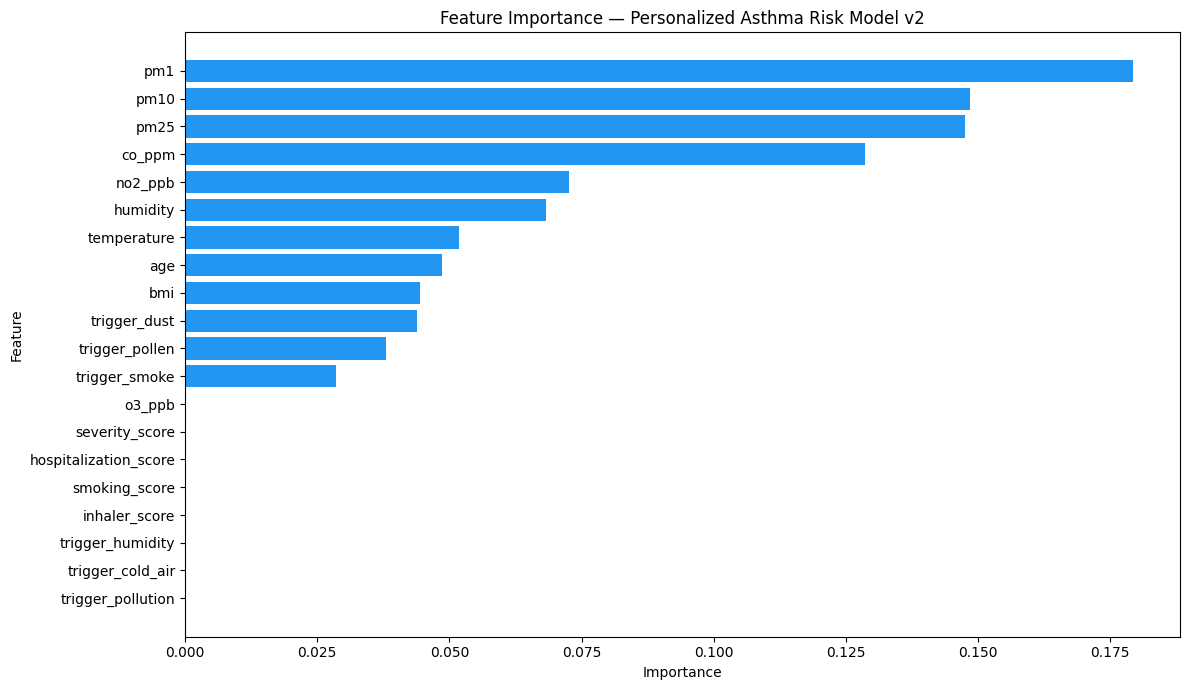

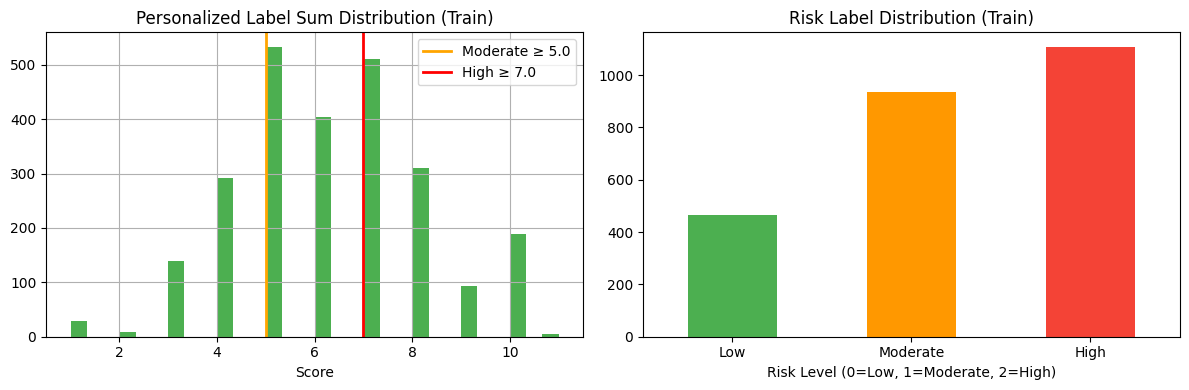


Model bundle saved to ../models/personalized_risk_rf_bundle_v2.pkl
Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled_v2.csv

--- Sample Prediction ---
Predicted label: High
Probabilities  → Low: 0.02  Moderate: 0.02  High: 0.96


In [6]:
# ============================================================
# train_personalized_risk_model_v2.py
# Personalized Asthma Risk Model — Corrected & Improved
# Fixes: leakage, CPCB thresholds (asthma-adjusted), SMOTE,
#        temporal features, PM1 included, balanced labels
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
env_path = Path("../../backend/.env")
load_dotenv(dotenv_path=env_path)

MONGO_URI = os.getenv("MONGO_URI")
print("Mongo URI loaded:", MONGO_URI is not None)

client = MongoClient(MONGO_URI)
db = client["asthmaDB"]

sensor_collection = db["sensordatas"]
profile_collection = db["medicalprofiles"]

sensor_data = list(sensor_collection.find())
profile_data = list(profile_collection.find())

print("Total sensor documents fetched:", len(sensor_data))
print("Total medical profile documents fetched:", len(profile_data))

sensor_df = pd.DataFrame(sensor_data)
profile_df = pd.DataFrame(profile_data)

print("Sensor DF shape:", sensor_df.shape)
print("Profile DF shape:", profile_df.shape)

# ─────────────────────────────────────────────
# 2. CLEAN IDs & TYPES
# ─────────────────────────────────────────────
if "_id" in sensor_df.columns:
    sensor_df["_id"] = sensor_df["_id"].astype(str)
if "_id" in profile_df.columns:
    profile_df["_id"] = profile_df["_id"].astype(str)
if "userId" in profile_df.columns:
    profile_df["userId"] = profile_df["userId"].astype(str)

# ─────────────────────────────────────────────
# 3. PARSE TIMESTAMPS
# ─────────────────────────────────────────────
if "recordedAt" in sensor_df.columns:
    sensor_df["recordedAt"] = pd.to_datetime(sensor_df["recordedAt"], errors="coerce")
if "updatedAt" in profile_df.columns:
    profile_df["updatedAt"] = pd.to_datetime(profile_df["updatedAt"], errors="coerce")
if "createdAt" in profile_df.columns:
    profile_df["createdAt"] = pd.to_datetime(profile_df["createdAt"], errors="coerce")

# ─────────────────────────────────────────────
# 4. DEDUPLICATE PROFILES
# ─────────────────────────────────────────────
if "userId" in profile_df.columns:
    sort_col = "updatedAt" if "updatedAt" in profile_df.columns else "createdAt"
    if sort_col in profile_df.columns:
        profile_df = profile_df.sort_values(sort_col).drop_duplicates(subset=["userId"], keep="last")
    else:
        profile_df = profile_df.drop_duplicates(subset=["userId"], keep="last")

print("Profiles after dedup:", len(profile_df))

# ─────────────────────────────────────────────
# 5. SELECT REQUIRED COLUMNS
# ─────────────────────────────────────────────
required_sensor_cols = [
    "co_ppm", "o3_ppb", "no2_ppb",
    "temperature", "humidity",
    "pm1", "pm25", "pm10",
    "recordedAt"  # keep for temporal features
]

required_profile_cols = [
    "userId", "age", "asthma_severity", "known_triggers",
    "last_hospitalization", "rescue_inhaler_use",
    "smoking_status", "height_cm", "weight_kg"
]

sensor_df = sensor_df[[c for c in required_sensor_cols if c in sensor_df.columns]].copy()
profile_df = profile_df[[c for c in required_profile_cols if c in profile_df.columns]].copy()

# ─────────────────────────────────────────────
# 6. CLEAN NUMERICS
# ─────────────────────────────────────────────
numeric_sensor_cols = ["co_ppm", "o3_ppb", "no2_ppb", "temperature", "humidity", "pm1", "pm25", "pm10"]
for col in numeric_sensor_cols:
    if col in sensor_df.columns:
        sensor_df[col] = pd.to_numeric(sensor_df[col], errors="coerce")

sensor_df.dropna(subset=numeric_sensor_cols, inplace=True)

for col in ["age", "height_cm", "weight_kg"]:
    if col in profile_df.columns:
        profile_df[col] = pd.to_numeric(profile_df[col], errors="coerce")

profile_df.dropna(
    subset=["age", "asthma_severity", "last_hospitalization",
            "rescue_inhaler_use", "smoking_status"],
    inplace=True
)

print("Sensor rows after cleaning:", len(sensor_df))
print("Profile rows after cleaning:", len(profile_df))

# ─────────────────────────────────────────────
# FIX 1 — SPLIT SENSOR DATA BEFORE CROSS JOIN
# Prevents same sensor reading leaking into both train & test
# ─────────────────────────────────────────────
sensor_train, sensor_test = train_test_split(
    sensor_df, test_size=0.2, random_state=42
)
print(f"Sensor train: {len(sensor_train)} | Sensor test: {len(sensor_test)}")

# ─────────────────────────────────────────────
# HELPER: BUILD FEATURES FOR A SENSOR SPLIT
# ─────────────────────────────────────────────
def build_features(sensor_split, profile_df):
    """Cross join sensor split with all profiles, then engineer all features."""

    s = sensor_split.copy()
    p = profile_df.copy()

    # -- Temporal features (Fix 4) --
    if "recordedAt" in s.columns:
        s["hour"]        = s["recordedAt"].dt.hour.fillna(0).astype(int)
        s["month"]       = s["recordedAt"].dt.month.fillna(1).astype(int)
        s["day_of_week"] = s["recordedAt"].dt.dayofweek.fillna(0).astype(int)

        # Cyclical encoding so hour 23 and hour 0 are neighbours
        s["hour_sin"]    = np.sin(2 * np.pi * s["hour"] / 24)
        s["hour_cos"]    = np.cos(2 * np.pi * s["hour"] / 24)
        s["month_sin"]   = np.sin(2 * np.pi * s["month"] / 12)
        s["month_cos"]   = np.cos(2 * np.pi * s["month"] / 12)

    s.drop(columns=["recordedAt"], errors="ignore", inplace=True)

    # -- Cross join --
    s["_tmp_key"] = 1
    p["_tmp_key"] = 1
    df = s.merge(p, on="_tmp_key").drop(columns=["_tmp_key"])

    # -- Known triggers --
    def safe_trigger_list(x):
        if isinstance(x, list): return x
        if pd.isna(x):          return []
        s_ = str(x).strip()
        return [] if s_ == "" else [s_]

    df["known_triggers"] = df["known_triggers"].apply(safe_trigger_list)

    # -- Medical score maps --
    severity_map = {
        "Intermittent": 0.20,
        "Mild Persistent": 0.40,
        "Moderate Persistent": 0.70,
        "Severe Persistent": 1.00
    }
    hospitalization_map = {
        "Never": 0.00,
        "More than 1 year ago": 0.30,
        "Within last year": 0.70,
        "Within last 3 months": 1.00
    }
    inhaler_map = {
        "Rarely": 0.20,
        "Sometimes": 0.50,
        "Often": 0.80,
        "Daily": 1.00
    }
    smoking_map = {
        "Non-smoker": 0.00,
        "Passive smoker": 0.40,
        "Former smoker": 0.30,
        "Current smoker": 1.00
    }

    df["severity_score"]       = df["asthma_severity"].map(severity_map).fillna(0.0)
    df["hospitalization_score"]= df["last_hospitalization"].map(hospitalization_map).fillna(0.0)
    df["inhaler_score"]        = df["rescue_inhaler_use"].map(inhaler_map).fillna(0.0)
    df["smoking_score"]        = df["smoking_status"].map(smoking_map).fillna(0.0)

    # -- BMI --
    def compute_bmi(w, h):
        if pd.isna(w) or pd.isna(h) or h == 0: return 0.0
        return w / ((h / 100.0) ** 2)

    df["bmi"] = df.apply(lambda r: compute_bmi(r["weight_kg"], r["height_cm"]), axis=1)

    # -- Trigger flags --
    def encode_trigger_flags(tlist):
        tlist = [str(t).lower() for t in tlist]
        return pd.Series({
            "trigger_dust":      int(any("dust"      in t for t in tlist)),
            "trigger_pollen":    int(any("pollen"    in t or "seasonal" in t for t in tlist)),
            "trigger_smoke":     int(any("smoke"     in t for t in tlist)),
            "trigger_humidity":  int(any("humidity"  in t or "damp"     in t for t in tlist)),
            "trigger_cold_air":  int(any("cold"      in t for t in tlist)),
            "trigger_pollution": int(any("pollution" in t or "traffic"  in t for t in tlist))
        })

    trigger_flags = df["known_triggers"].apply(encode_trigger_flags)
    df = pd.concat([df, trigger_flags], axis=1)

    # ─────────────────────────────────────────────
    # FIX 2 — ASTHMA-ADJUSTED CPCB/NAQI THRESHOLDS
    # For asthma patients, sensitivity is 2–3× higher
    # than general public thresholds.
    # Sources: CPCB NAQI 2014, GINA guidelines 2023,
    #          WHO Air Quality Guidelines 2021
    # ─────────────────────────────────────────────

    # PM1 (no official CPCB standard; use WHO-based asthma guidance)
    # Asthma patients react at lower PM1 levels (ultrafine particles)
    def label_pm1_asthma(x):
        if x > 20:      # High — ultrafine particle overload
            return 2
        elif x >= 8:    # Moderate — noticeable irritation
            return 1
        else:           # Low
            return 0

    # PM2.5 — CPCB 24hr: Good≤30, Satisfactory≤60, Moderate≤90
    # Asthma threshold tightened: trigger risk starts at 30 µg/m³
    def label_pm25_asthma(x):
        if x > 60:      # CPCB "Moderate+" → High risk for asthma
            return 2
        elif x >= 30:   # CPCB "Satisfactory" → already risky for asthma
            return 1
        else:
            return 0

    # PM10 — CPCB 24hr: Good≤50, Satisfactory≤100
    # Asthma patients sensitive from 50 µg/m³
    def label_pm10_asthma(x):
        if x > 100:     # CPCB "Moderate" → High for asthma
            return 2
        elif x >= 50:   # CPCB "Satisfactory" → Moderate for asthma
            return 1
        else:
            return 0

    # NO2 — CPCB: Good≤40 µg/m³; 1ppb ≈ 1.88 µg/m³
    # Asthma: WHO recommends <25 µg/m³ annual; short-term spikes harmful
    def label_no2_asthma(x_ppb):
        x = x_ppb * 1.88  # convert to µg/m³
        if x > 180:     # CPCB Poor → High
            return 2
        elif x >= 40:   # CPCB "Good" ceiling → Moderate for asthma
            return 1
        else:
            return 0

    # O3 — CPCB: Good≤50 µg/m³; 1ppb ≈ 1.96 µg/m³
    # O3 is one of the strongest asthma triggers
    def label_o3_asthma(x_ppb):
        x = x_ppb * 1.96  # convert to µg/m³
        if x > 100:     # CPCB Moderate → High for asthma
            return 2
        elif x >= 50:   # CPCB Good ceiling → already problematic for asthma
            return 1
        else:
            return 0

    # CO — CPCB: Good≤1 mg/m³; 1ppm ≈ 1.145 mg/m³
    def label_co_asthma(x_ppm):
        x = x_ppm * 1.145  # convert to mg/m³
        if x > 10:      # CPCB Poor
            return 2
        elif x >= 2.0:  # Moderate; asthma patients affected earlier
            return 1
        else:
            return 0

    # Temperature — physiological, not CPCB
    # Extreme cold (<10°C) and heat (>32°C) are asthma triggers
    def label_temperature_asthma(x):
        if x <= 10 or x >= 32:   # tighter than general (was 15/35)
            return 2
        elif (10 < x < 16) or (28 < x < 32):
            return 1
        else:
            return 0

    # Humidity — high humidity promotes mold/dust mites (key asthma triggers)
    # Low humidity dries airways
    def label_humidity_asthma(x):
        if x > 65 or x < 25:    # tighter upper bound than general (was 60)
            return 2
        elif x > 55 or x < 35:
            return 1
        else:
            return 0

    # Apply all labels
    df["pm1_label"]         = df["pm1"].apply(label_pm1_asthma)
    df["pm25_label"]        = df["pm25"].apply(label_pm25_asthma)
    df["pm10_label"]        = df["pm10"].apply(label_pm10_asthma)
    df["no2_label"]         = df["no2_ppb"].apply(label_no2_asthma)
    df["o3_label"]          = df["o3_ppb"].apply(label_o3_asthma)
    df["co_label"]          = df["co_ppm"].apply(label_co_asthma)
    df["temperature_label"] = df["temperature"].apply(label_temperature_asthma)
    df["humidity_label"]    = df["humidity"].apply(label_humidity_asthma)

    # Environment label sum (max = 16)
    env_label_cols = [
        "pm1_label", "pm25_label", "pm10_label",
        "no2_label", "o3_label", "co_label",
        "temperature_label", "humidity_label"
    ]
    df["environment_label_sum"] = df[env_label_cols].sum(axis=1)

    # Medical risk score
    def medical_label_score(row):
        return (
            row["severity_score"]       * 3.0 +
            row["hospitalization_score"]* 2.0 +
            row["inhaler_score"]        * 2.0 +
            row["smoking_score"]        * 1.5 +
            row["trigger_dust"]         * 0.5 +
            row["trigger_pollen"]       * 0.5 +
            row["trigger_smoke"]        * 0.5 +
            row["trigger_humidity"]     * 0.5 +
            row["trigger_cold_air"]     * 0.5 +
            row["trigger_pollution"]    * 0.5
        )

    df["medical_label_score"] = df.apply(medical_label_score, axis=1)

    def medical_risk_band(score):
        if score >= 4.5: return 2
        elif score >= 2.0: return 1
        else: return 0

    df["medical_risk_band"] = df["medical_label_score"].apply(medical_risk_band)

    # Combined score
    df["personalized_label_sum"] = df["environment_label_sum"] + (df["medical_risk_band"] * 2)

    return df


# Build train and test DataFrames independently
df_train = build_features(sensor_train, profile_df)
df_test  = build_features(sensor_test,  profile_df)

print("Train rows:", len(df_train))
print("Test rows:",  len(df_test))

# ─────────────────────────────────────────────
# FIX 3 — PERCENTILE-BASED LABEL THRESHOLDS
# Gives balanced class distribution
# ─────────────────────────────────────────────
p33 = df_train["personalized_label_sum"].quantile(0.33)
p66 = df_train["personalized_label_sum"].quantile(0.66)
print(f"\nPercentile thresholds — Moderate: {p33:.2f}, High: {p66:.2f}")

def final_risk_label(total, t_mod=p33, t_high=p66):
    if total >= t_high:   return 2  # High
    elif total >= t_mod:  return 1  # Moderate
    else:                 return 0  # Low

df_train["risk_label"] = df_train["personalized_label_sum"].apply(final_risk_label)
df_test["risk_label"]  = df_test["personalized_label_sum"].apply(final_risk_label)

print("\nTrain label distribution:")
print(df_train["risk_label"].value_counts())
print(df_train["risk_label"].value_counts(normalize=True).mul(100).round(1))

print("\nTest label distribution:")
print(df_test["risk_label"].value_counts())

# ─────────────────────────────────────────────
# 7. FEATURE COLUMNS
# ─────────────────────────────────────────────
feature_cols = [
    # Sensor (raw)
    "co_ppm", "o3_ppb", "no2_ppb",
    "temperature", "humidity",
    "pm1", "pm25", "pm10",

    # Patient
    "age", "bmi",

    # Medical scores
    "severity_score", "hospitalization_score",
    "inhaler_score", "smoking_score",

    # Trigger flags
    "trigger_dust", "trigger_pollen", "trigger_smoke",
    "trigger_humidity", "trigger_cold_air", "trigger_pollution",

    # Temporal (Fix 4)
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "day_of_week"
]

# Only keep cols that exist (temporal cols absent if recordedAt was missing)
feature_cols = [c for c in feature_cols if c in df_train.columns]

X_train = df_train[feature_cols].copy()
y_train = df_train["risk_label"].copy()
X_test  = df_test[feature_cols].copy()
y_test  = df_test["risk_label"].copy()

# Clip outlier
X_train["co_ppm"] = X_train["co_ppm"].clip(upper=50)
X_test["co_ppm"]  = X_test["co_ppm"].clip(upper=50)

print("\nX_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

# ─────────────────────────────────────────────
# FIX 2 — SMOTE FOR CLASS IMBALANCE
# ─────────────────────────────────────────────
class_counts = y_train.value_counts()
print("\nBefore SMOTE:", class_counts.to_dict())

# Target: upsample minority classes to at least 20% of dataset
n_total      = len(y_train)
target_count = max(int(n_total * 0.20), class_counts.max())

sampling_strategy = {}
for cls, cnt in class_counts.items():
    if cnt < target_count:
        sampling_strategy[cls] = target_count

if sampling_strategy:
    k_neighbors = min(5, min(class_counts.values) - 1)
    k_neighbors = max(1, k_neighbors)  # must be at least 1
    sm = SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42,
        k_neighbors=k_neighbors
    )
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())
else:
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE not needed — classes already balanced")

# ─────────────────────────────────────────────
# 8. TRAIN MODEL
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)
print("\nModel trained successfully")

# ─────────────────────────────────────────────
# 9. EVALUATE
# ─────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("\n" + "="*50)
print("EVALUATION ON HELD-OUT TEST SET")
print("="*50)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ─────────────────────────────────────────────
# FIX 5 — CROSS-VALIDATION (honest estimate)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, random_state=42,
        class_weight="balanced", n_jobs=-1
    ),
    X_train_res, y_train_res,
    cv=cv, scoring="f1_macro"
)
print(f"\n5-Fold CV F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("(This is a better generalization estimate than single-split accuracy)")

# ─────────────────────────────────────────────
# 10. FEATURE IMPORTANCE PLOT
# ─────────────────────────────────────────────
feature_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 7))
plt.barh(feature_importance["feature"], feature_importance["importance"], color="#2196F3")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Personalized Asthma Risk Model v2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../models/feature_importance_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 11. LABEL DISTRIBUTION PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train["personalized_label_sum"].hist(bins=30, ax=axes[0], color="#4CAF50")
axes[0].axvline(p33, color="orange", linewidth=2, label=f"Moderate ≥ {p33:.1f}")
axes[0].axvline(p66, color="red",    linewidth=2, label=f"High ≥ {p66:.1f}")
axes[0].set_title("Personalized Label Sum Distribution (Train)")
axes[0].set_xlabel("Score")
axes[0].legend()

df_train["risk_label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#4CAF50", "#FF9800", "#F44336"]
)
axes[1].set_title("Risk Label Distribution (Train)")
axes[1].set_xlabel("Risk Level (0=Low, 1=Moderate, 2=High)")
axes[1].set_xticklabels(["Low", "Moderate", "High"], rotation=0)
plt.tight_layout()
plt.savefig("../models/label_distribution_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 12. SAVE MODEL BUNDLE
# ─────────────────────────────────────────────
os.makedirs("../models", exist_ok=True)

bundle = {
    "model":        rf_model,
    "features":     feature_cols,
    "label_map":    {0: "Low", 1: "Moderate", 2: "High"},
    "thresholds": {
        "moderate_threshold": float(p33),
        "high_threshold":     float(p66)
    },
    "notes": {
        "pm_standard":    "Asthma-adjusted CPCB/NAQI thresholds",
        "label_method":   "Percentile-based (33rd/66th) on training set",
        "smote":          "Applied to minority classes",
        "temporal":       "Cyclical hour/month encoding from recordedAt",
        "leakage_fix":    "Sensor split done BEFORE cross join with profiles"
    }
}

joblib.dump(bundle, "../models/personalized_risk_rf_bundle_v2.pkl")
print("\nModel bundle saved to ../models/personalized_risk_rf_bundle_v2.pkl")

# ─────────────────────────────────────────────
# 13. SAVE LABELED DATA
# ─────────────────────────────────────────────
os.makedirs("../data_exports", exist_ok=True)

export_cols = [
    "co_ppm", "o3_ppb", "no2_ppb", "temperature", "humidity",
    "pm1", "pm25", "pm10",
    "age", "asthma_severity", "last_hospitalization",
    "rescue_inhaler_use", "smoking_status",
    "environment_label_sum", "medical_label_score",
    "medical_risk_band", "personalized_label_sum", "risk_label"
]

full_df = pd.concat([df_train, df_test], ignore_index=True)
full_df[[c for c in export_cols if c in full_df.columns]].to_csv(
    "../data_exports/personalized_risk_training_data_labeled_v2.csv", index=False
)
print("Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled_v2.csv")

# ─────────────────────────────────────────────
# 14. SAMPLE PREDICTION
# ─────────────────────────────────────────────
sample   = X_test.iloc[[0]]
pred     = rf_model.predict(sample)[0]
probs    = rf_model.predict_proba(sample)[0]
label_map = {0: "Low", 1: "Moderate", 2: "High"}

print("\n--- Sample Prediction ---")
print("Predicted label:", label_map[pred])
print("Probabilities  → Low: {:.2f}  Moderate: {:.2f}  High: {:.2f}".format(*probs))

Mongo URI loaded: True
Total sensor documents fetched: 1917
Total medical profile documents fetched: 2
Sensor DF shape: (1917, 12)
Profile DF shape: (2, 15)
Profiles after dedup: 2
Rows dropped due to bad NO2 readings: 5

Sensor stats after cleaning:
        co_ppm  no2_ppb      pm1     pm25     pm10
count  1912.00  1912.00  1912.00  1912.00  1912.00
mean      2.75     9.89    47.92    98.39   113.54
std       4.90     4.46    57.13   151.15   178.15
min       0.65     0.04    -1.00    -1.00    -1.00
25%       1.26     7.05    22.00    32.00    34.00
50%       1.88     9.10    24.00    35.00    41.00
75%       2.63    11.54    40.00    61.25    71.00
max      50.00    23.44   200.00   500.00   600.00
Sensor rows after cleaning: 1912
Profile rows after cleaning: 2
Sensor train: 1529 | Sensor test: 383
Train rows: 3058
Test rows: 766

Percentile thresholds — Moderate: 4.00, High: 5.00

Train label distribution:
risk_label
1    1174
2    1110
0     774
Name: count, dtype: int64
risk_label

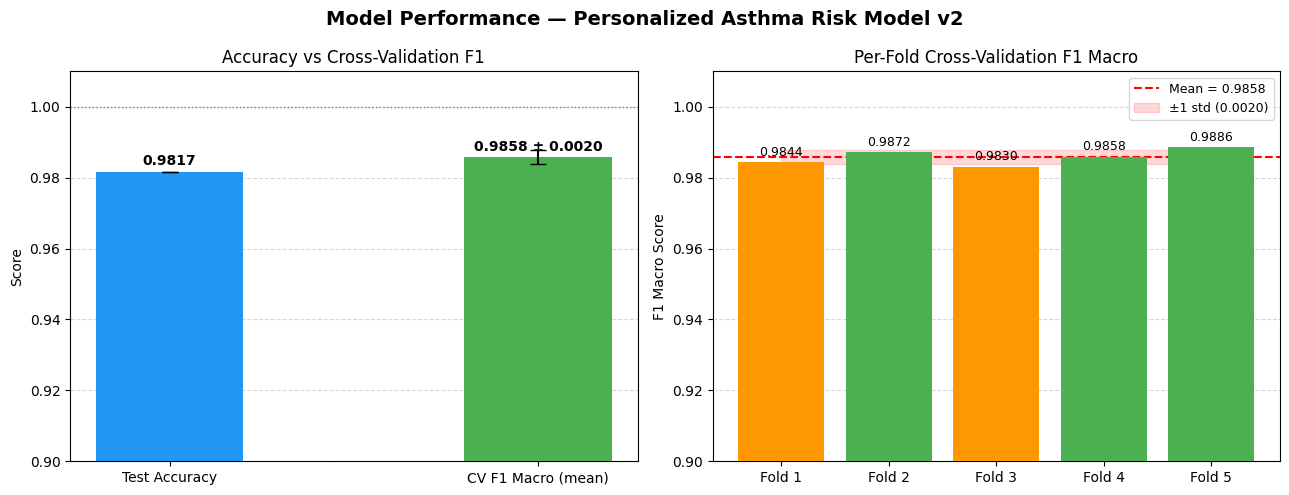


PERFORMANCE SUMMARY
  Test Accuracy        : 0.9817 (98.17%)
  CV F1 Macro (mean)   : 0.9858
  CV F1 Macro (std)    : ±0.0020
  CV F1 Macro (range)  : 0.9830 – 0.9886

Top 10 Features:
      feature  importance
         pm25    0.218236
         pm10    0.202034
          pm1    0.148541
       co_ppm    0.142963
      no2_ppb    0.103064
     humidity    0.092665
  temperature    0.089745
          bmi    0.000796
trigger_smoke    0.000715
          age    0.000515


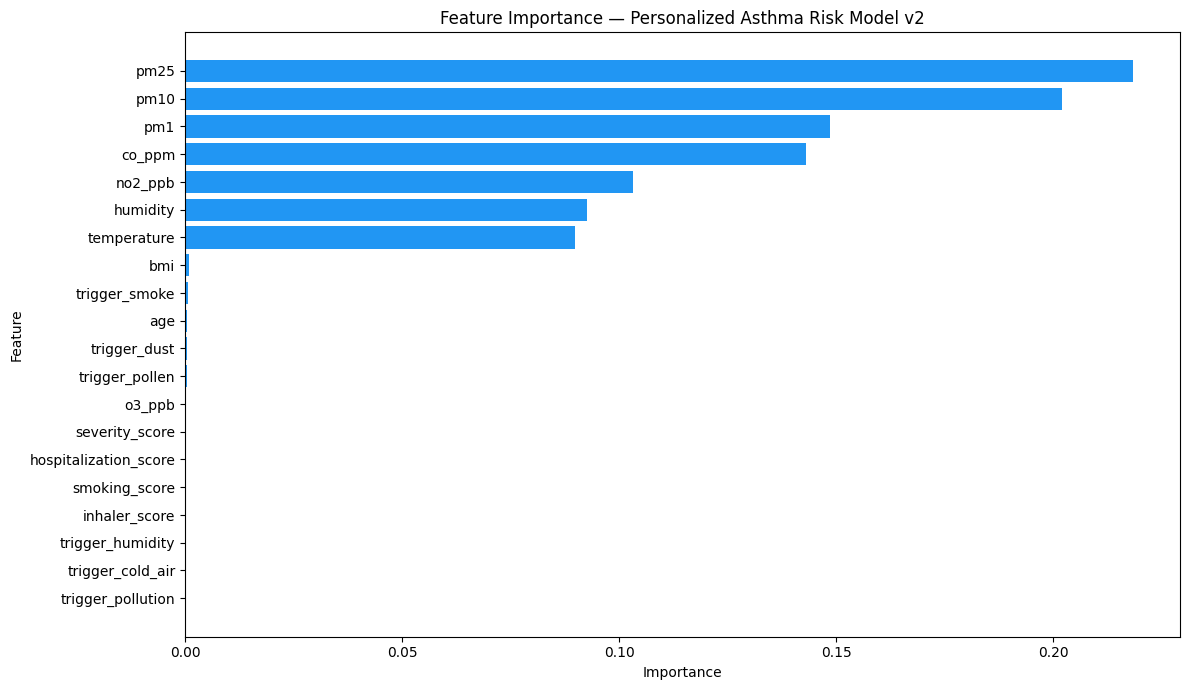

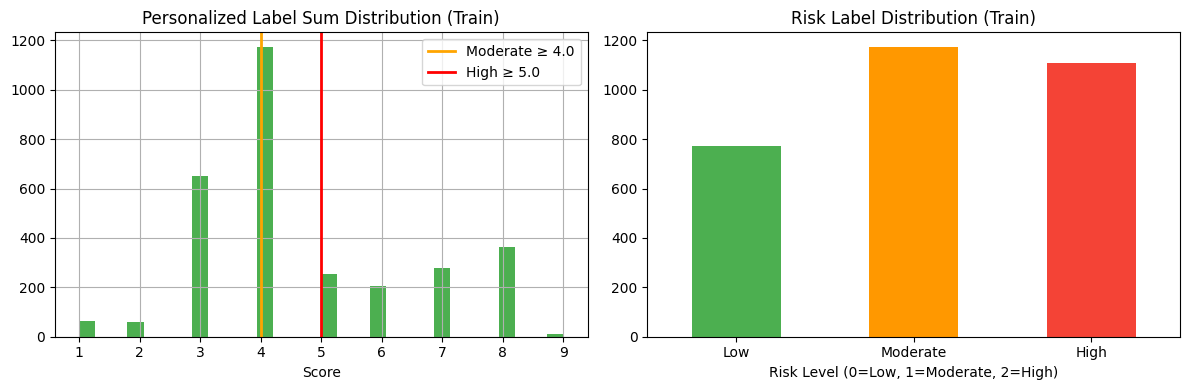


Model bundle saved to ../models/personalized_risk_rf_bundle_v2.pkl
Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled_v2.csv

--- Sample Prediction ---
Predicted label: Low
Probabilities  → Low: 0.88  Moderate: 0.12  High: 0.00


In [1]:
# ============================================================
# train_personalized_risk_model_v2.py
# Personalized Asthma Risk Model — Corrected & Improved
# Fixes: leakage, CPCB thresholds (asthma-adjusted), SMOTE,
#        temporal features, PM1 included, balanced labels
# ============================================================

import os
from pathlib import Path

import pandas as pd
import numpy as np
from pymongo import MongoClient
from dotenv import load_dotenv
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
env_path = Path("../../backend/.env")
load_dotenv(dotenv_path=env_path)

MONGO_URI = os.getenv("MONGO_URI")
print("Mongo URI loaded:", MONGO_URI is not None)

client = MongoClient(MONGO_URI)
db = client["asthmaDB"]

sensor_collection = db["sensordatas"]
profile_collection = db["medicalprofiles"]

sensor_data = list(sensor_collection.find())
profile_data = list(profile_collection.find())

print("Total sensor documents fetched:", len(sensor_data))
print("Total medical profile documents fetched:", len(profile_data))

sensor_df = pd.DataFrame(sensor_data)
profile_df = pd.DataFrame(profile_data)

print("Sensor DF shape:", sensor_df.shape)
print("Profile DF shape:", profile_df.shape)

# ─────────────────────────────────────────────
# 2. CLEAN IDs & TYPES
# ─────────────────────────────────────────────
if "_id" in sensor_df.columns:
    sensor_df["_id"] = sensor_df["_id"].astype(str)
if "_id" in profile_df.columns:
    profile_df["_id"] = profile_df["_id"].astype(str)
if "userId" in profile_df.columns:
    profile_df["userId"] = profile_df["userId"].astype(str)

# ─────────────────────────────────────────────
# 3. PARSE TIMESTAMPS
# ─────────────────────────────────────────────
if "recordedAt" in sensor_df.columns:
    sensor_df["recordedAt"] = pd.to_datetime(sensor_df["recordedAt"], errors="coerce")
if "updatedAt" in profile_df.columns:
    profile_df["updatedAt"] = pd.to_datetime(profile_df["updatedAt"], errors="coerce")
if "createdAt" in profile_df.columns:
    profile_df["createdAt"] = pd.to_datetime(profile_df["createdAt"], errors="coerce")

# ─────────────────────────────────────────────
# 4. DEDUPLICATE PROFILES
# ─────────────────────────────────────────────
if "userId" in profile_df.columns:
    sort_col = "updatedAt" if "updatedAt" in profile_df.columns else "createdAt"
    if sort_col in profile_df.columns:
        profile_df = profile_df.sort_values(sort_col).drop_duplicates(subset=["userId"], keep="last")
    else:
        profile_df = profile_df.drop_duplicates(subset=["userId"], keep="last")

print("Profiles after dedup:", len(profile_df))

# ─────────────────────────────────────────────
# 5. SELECT REQUIRED COLUMNS
# ─────────────────────────────────────────────
required_sensor_cols = [
    "co_ppm", "o3_ppb", "no2_ppb",
    "temperature", "humidity",
    "pm1", "pm25", "pm10",
    "recordedAt"  # keep for temporal features
]

required_profile_cols = [
    "userId", "age", "asthma_severity", "known_triggers",
    "last_hospitalization", "rescue_inhaler_use",
    "smoking_status", "height_cm", "weight_kg"
]

sensor_df = sensor_df[[c for c in required_sensor_cols if c in sensor_df.columns]].copy()
profile_df = profile_df[[c for c in required_profile_cols if c in profile_df.columns]].copy()

# ─────────────────────────────────────────────
# 6. CLEAN NUMERICS
# ─────────────────────────────────────────────
numeric_sensor_cols = ["co_ppm", "o3_ppb", "no2_ppb", "temperature", "humidity", "pm1", "pm25", "pm10"]
for col in numeric_sensor_cols:
    if col in sensor_df.columns:
        sensor_df[col] = pd.to_numeric(sensor_df[col], errors="coerce")

sensor_df.dropna(subset=numeric_sensor_cols, inplace=True)

# ── Clip sensor outliers ──────────────────────
# CO: physical max in real environments ~50 ppm
sensor_df["co_ppm"] = sensor_df["co_ppm"].clip(upper=50)

# PM caps — values above these are sensor spikes, not real readings
sensor_df["pm1"]  = sensor_df["pm1"].clip(upper=200)
sensor_df["pm25"] = sensor_df["pm25"].clip(upper=500)
sensor_df["pm10"] = sensor_df["pm10"].clip(upper=600)

# NO2 — values at or near zero (e.g. 1.4e-13) are bad sensor readings
sensor_df["no2_ppb"] = sensor_df["no2_ppb"].where(
    sensor_df["no2_ppb"] > 0.01, other=np.nan
)
rows_before = len(sensor_df)
sensor_df.dropna(subset=["no2_ppb"], inplace=True)
print(f"Rows dropped due to bad NO2 readings: {rows_before - len(sensor_df)}")

print("\nSensor stats after cleaning:")
print(sensor_df[["co_ppm", "no2_ppb", "pm1", "pm25", "pm10"]].describe().round(2))

for col in ["age", "height_cm", "weight_kg"]:
    if col in profile_df.columns:
        profile_df[col] = pd.to_numeric(profile_df[col], errors="coerce")

profile_df.dropna(
    subset=["age", "asthma_severity", "last_hospitalization",
            "rescue_inhaler_use", "smoking_status"],
    inplace=True
)

print("Sensor rows after cleaning:", len(sensor_df))
print("Profile rows after cleaning:", len(profile_df))

# ─────────────────────────────────────────────
# FIX 1 — SPLIT SENSOR DATA BEFORE CROSS JOIN
# Prevents same sensor reading leaking into both train & test
# ─────────────────────────────────────────────
sensor_train, sensor_test = train_test_split(
    sensor_df, test_size=0.2, random_state=42
)
print(f"Sensor train: {len(sensor_train)} | Sensor test: {len(sensor_test)}")

# ─────────────────────────────────────────────
# HELPER: BUILD FEATURES FOR A SENSOR SPLIT
# ─────────────────────────────────────────────
def build_features(sensor_split, profile_df):
    """Cross join sensor split with all profiles, then engineer all features."""

    s = sensor_split.copy()
    p = profile_df.copy()

    # -- Temporal features (Fix 4) --
    if "recordedAt" in s.columns:
        s["hour"]        = s["recordedAt"].dt.hour.fillna(0).astype(int)
        s["month"]       = s["recordedAt"].dt.month.fillna(1).astype(int)
        s["day_of_week"] = s["recordedAt"].dt.dayofweek.fillna(0).astype(int)

        # Cyclical encoding so hour 23 and hour 0 are neighbours
        s["hour_sin"]    = np.sin(2 * np.pi * s["hour"] / 24)
        s["hour_cos"]    = np.cos(2 * np.pi * s["hour"] / 24)
        s["month_sin"]   = np.sin(2 * np.pi * s["month"] / 12)
        s["month_cos"]   = np.cos(2 * np.pi * s["month"] / 12)

    s.drop(columns=["recordedAt"], errors="ignore", inplace=True)

    # -- Cross join --
    s["_tmp_key"] = 1
    p["_tmp_key"] = 1
    df = s.merge(p, on="_tmp_key").drop(columns=["_tmp_key"])

    # -- Known triggers --
    def safe_trigger_list(x):
        if isinstance(x, list): return x
        if pd.isna(x):          return []
        s_ = str(x).strip()
        return [] if s_ == "" else [s_]

    df["known_triggers"] = df["known_triggers"].apply(safe_trigger_list)

    # -- Medical score maps --
    severity_map = {
        "Intermittent": 0.20,
        "Mild Persistent": 0.40,
        "Moderate Persistent": 0.70,
        "Severe Persistent": 1.00
    }
    hospitalization_map = {
        "Never": 0.00,
        "More than 1 year ago": 0.30,
        "Within last year": 0.70,
        "Within last 3 months": 1.00
    }
    inhaler_map = {
        "Rarely": 0.20,
        "Sometimes": 0.50,
        "Often": 0.80,
        "Daily": 1.00
    }
    smoking_map = {
        "Non-smoker": 0.00,
        "Passive smoker": 0.40,
        "Former smoker": 0.30,
        "Current smoker": 1.00
    }

    df["severity_score"]       = df["asthma_severity"].map(severity_map).fillna(0.0)
    df["hospitalization_score"]= df["last_hospitalization"].map(hospitalization_map).fillna(0.0)
    df["inhaler_score"]        = df["rescue_inhaler_use"].map(inhaler_map).fillna(0.0)
    df["smoking_score"]        = df["smoking_status"].map(smoking_map).fillna(0.0)

    # -- BMI --
    def compute_bmi(w, h):
        if pd.isna(w) or pd.isna(h) or h == 0: return 0.0
        return w / ((h / 100.0) ** 2)

    df["bmi"] = df.apply(lambda r: compute_bmi(r["weight_kg"], r["height_cm"]), axis=1)

    # -- Trigger flags --
    def encode_trigger_flags(tlist):
        tlist = [str(t).lower() for t in tlist]
        return pd.Series({
            "trigger_dust":      int(any("dust"      in t for t in tlist)),
            "trigger_pollen":    int(any("pollen"    in t or "seasonal" in t for t in tlist)),
            "trigger_smoke":     int(any("smoke"     in t for t in tlist)),
            "trigger_humidity":  int(any("humidity"  in t or "damp"     in t for t in tlist)),
            "trigger_cold_air":  int(any("cold"      in t for t in tlist)),
            "trigger_pollution": int(any("pollution" in t or "traffic"  in t for t in tlist))
        })

    trigger_flags = df["known_triggers"].apply(encode_trigger_flags)
    df = pd.concat([df, trigger_flags], axis=1)

    # ─────────────────────────────────────────────
    # FIX 2 — ASTHMA-ADJUSTED CPCB/NAQI THRESHOLDS
    # For asthma patients, sensitivity is 2–3× higher
    # than general public thresholds.
    # Sources: CPCB NAQI 2014, GINA guidelines 2023,
    #          WHO Air Quality Guidelines 2021
    # ─────────────────────────────────────────────

    # PM1 (no official CPCB standard; use WHO-based asthma guidance)
    # Asthma patients react at lower PM1 levels (ultrafine particles)
    def label_pm1_asthma(x):
        if x > 35:      # High — ultrafine particle overload
            return 2
        elif x >= 10:    # Moderate — noticeable irritation
            return 1
        else:           # Low
            return 0

    # PM2.5 — CPCB 24hr: Good≤30, Satisfactory≤60, Moderate≤90
    # Asthma threshold tightened: trigger risk starts at 30 µg/m³
    def label_pm25_asthma(x):
        if x > 60:      # CPCB "Moderate+" → High risk for asthma
            return 2
        elif x >= 30:   # CPCB "Satisfactory" → already risky for asthma
            return 1
        else:
            return 0

    # PM10 — CPCB 24hr: Good≤50, Satisfactory≤100
    # Asthma patients sensitive from 50 µg/m³
    def label_pm10_asthma(x):
        if x > 100:     # CPCB "Moderate" → High for asthma
            return 2
        elif x >= 50:   # CPCB "Satisfactory" → Moderate for asthma
            return 1
        else:
            return 0

    # NO2 — CPCB: Good≤40 µg/m³; 1ppb ≈ 1.88 µg/m³
    # Asthma: WHO recommends <25 µg/m³ annual; short-term spikes harmful
    def label_no2_asthma(x_ppb):
        x = x_ppb * 1.88  # convert to µg/m³
        if x > 180:     # CPCB Poor → High
            return 2
        elif x >= 40:   # CPCB "Good" ceiling → Moderate for asthma
            return 1
        else:
            return 0

    # O3 — CPCB: Good≤50 µg/m³; 1ppb ≈ 1.96 µg/m³
    # O3 is one of the strongest asthma triggers
    def label_o3_asthma(x_ppb):
        x = x_ppb * 1.96  # convert to µg/m³
        if x > 100:     # CPCB Moderate → High for asthma
            return 2
        elif x >= 50:   # CPCB Good ceiling → already problematic for asthma
            return 1
        else:
            return 0

    # CO — CPCB: Good≤1 mg/m³; 1ppm ≈ 1.145 mg/m³
    def label_co_asthma(x_ppm):
        x = x_ppm * 1.145  # convert to mg/m³
        if x > 10:      # CPCB Poor
            return 2
        elif x >= 2.0:  # Moderate; asthma patients affected earlier
            return 1
        else:
            return 0

    # Temperature — physiological, not CPCB
    # Extreme cold (<10°C) and heat (>32°C) are asthma triggers
    def label_temperature_asthma(x):
        if x <= 10 or x >= 32:   # tighter than general (was 15/35)
            return 2
        elif (10 < x < 16) or (28 < x < 32):
            return 1
        else:
            return 0

    # Humidity — high humidity promotes mold/dust mites (key asthma triggers)
    # Low humidity dries airways
    def label_humidity_asthma(x):
        if x > 65 or x < 25:    # tighter upper bound than general (was 60)
            return 2
        elif x > 55 or x < 35:
            return 1
        else:
            return 0

    # Apply all labels
    df["pm1_label"]         = df["pm1"].apply(label_pm1_asthma)
    df["pm25_label"]        = df["pm25"].apply(label_pm25_asthma)
    df["pm10_label"]        = df["pm10"].apply(label_pm10_asthma)
    df["no2_label"]         = df["no2_ppb"].apply(label_no2_asthma)
    df["o3_label"]          = df["o3_ppb"].apply(label_o3_asthma)
    df["co_label"]          = df["co_ppm"].apply(label_co_asthma)
    df["temperature_label"] = df["temperature"].apply(label_temperature_asthma)
    df["humidity_label"]    = df["humidity"].apply(label_humidity_asthma)

    # Environment label sum (max = 16)
    env_label_cols = [
        "pm1_label", "pm25_label", "pm10_label",
        "no2_label", "o3_label", "co_label",
        "temperature_label", "humidity_label"
    ]
    df["environment_label_sum"] = df[env_label_cols].sum(axis=1)

    # Medical risk score
    # ── Max possible score breakdown ──────────────
    # severity_score       max=1.0  × 3.0 = 3.0
    # hospitalization_score max=1.0 × 2.0 = 2.0
    # inhaler_score        max=1.0  × 2.0 = 2.0
    # smoking_score        max=1.0  × 1.5 = 1.5
    # age_score            max=1.0  × 1.0 = 1.0  ← NEW
    # bmi_score            max=1.0  × 0.8 = 0.8  ← NEW
    # 6 triggers           max=1    × 0.5 = 3.0
    # ─────────────────────────────────────────────
    # Old max = 3+2+2+1.5+3   = 11.5
    # New max = 3+2+2+1.5+1+0.8+3 = 13.3
    # Bands scaled up proportionally to keep
    # the same relative Low/Moderate/High split:
    #   Old: Low<2.0, Moderate<4.5, High≥4.5
    #   New: Low<2.5, Moderate<5.5, High≥5.5
    #   (scaled by factor 13.3/11.5 ≈ 1.16)
    def medical_label_score(row):

        # Age risk — older patients have reduced lung function (GINA 2023)
        age = row["age"]
        if age >= 60:
            age_score = 1.0   # significantly elevated risk
        elif age >= 40:
            age_score = 0.5   # moderate elevation
        else:
            age_score = 0.0   # younger — lower baseline risk

        # BMI risk — obesity reduces lung capacity; underweight also vulnerable
        bmi = row["bmi"]
        if bmi >= 30:         # obese
            bmi_score = 1.0
        elif bmi >= 25:       # overweight
            bmi_score = 0.5
        elif bmi < 18.5:      # underweight — reduced respiratory reserve
            bmi_score = 0.5
        else:
            bmi_score = 0.0   # healthy BMI range

        return (
            row["severity_score"]       * 3.0 +
            row["hospitalization_score"]* 2.0 +
            row["inhaler_score"]        * 2.0 +
            row["smoking_score"]        * 1.5 +
            age_score                   * 1.0 +   # ← now in label
            bmi_score                   * 0.8 +   # ← now in label
            row["trigger_dust"]         * 0.5 +
            row["trigger_pollen"]       * 0.5 +
            row["trigger_smoke"]        * 0.5 +
            row["trigger_humidity"]     * 0.5 +
            row["trigger_cold_air"]     * 0.5 +
            row["trigger_pollution"]    * 0.5
        )

    df["medical_label_score"] = df.apply(medical_label_score, axis=1)

    # Thresholds scaled up proportionally to account for
    # the two new features (old max 11.5 → new max 13.3)
    # so the Low/Moderate/High split stays the same
    def medical_risk_band(score):
        if score >= 5.5:   return 2   # was 4.5
        elif score >= 2.5: return 1   # was 2.0
        else:              return 0

    df["medical_risk_band"] = df["medical_label_score"].apply(medical_risk_band)

    # Combined score — medical_risk_band × 2 keeps its weight
    # relative to environment_label_sum (max=16) unchanged
    df["personalized_label_sum"] = df["environment_label_sum"] + (df["medical_risk_band"] * 2)

    return df


# Build train and test DataFrames independently
df_train = build_features(sensor_train, profile_df)
df_test  = build_features(sensor_test,  profile_df)

print("Train rows:", len(df_train))
print("Test rows:",  len(df_test))

# ─────────────────────────────────────────────
# FIX 3 — PERCENTILE-BASED LABEL THRESHOLDS
# Gives balanced class distribution
# ─────────────────────────────────────────────
p33 = df_train["personalized_label_sum"].quantile(0.33)
p66 = df_train["personalized_label_sum"].quantile(0.66)
print(f"\nPercentile thresholds — Moderate: {p33:.2f}, High: {p66:.2f}")

def final_risk_label(total, t_mod=p33, t_high=p66):
    if total >= t_high:   return 2  # High
    elif total >= t_mod:  return 1  # Moderate
    else:                 return 0  # Low

df_train["risk_label"] = df_train["personalized_label_sum"].apply(final_risk_label)
df_test["risk_label"]  = df_test["personalized_label_sum"].apply(final_risk_label)

print("\nTrain label distribution:")
print(df_train["risk_label"].value_counts())
print(df_train["risk_label"].value_counts(normalize=True).mul(100).round(1))

print("\nTest label distribution:")
print(df_test["risk_label"].value_counts())

# ─────────────────────────────────────────────
# 7. FEATURE COLUMNS
# ─────────────────────────────────────────────
feature_cols = [
    # Sensor (raw)
    "co_ppm", "o3_ppb", "no2_ppb",
    "temperature", "humidity",
    "pm1", "pm25", "pm10",

    # Patient
    "age", "bmi",

    # Medical scores
    "severity_score", "hospitalization_score",
    "inhaler_score", "smoking_score",

    # Trigger flags
    "trigger_dust", "trigger_pollen", "trigger_smoke",
    "trigger_humidity", "trigger_cold_air", "trigger_pollution",

    # Temporal (Fix 4)
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "day_of_week"
]

# Only keep cols that exist (temporal cols absent if recordedAt was missing)
feature_cols = [c for c in feature_cols if c in df_train.columns]

X_train = df_train[feature_cols].copy()
y_train = df_train["risk_label"].copy()
X_test  = df_test[feature_cols].copy()
y_test  = df_test["risk_label"].copy()

# co_ppm already clipped at source during sensor cleaning
print("\nX_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

# ─────────────────────────────────────────────
# FIX 2 — SMOTE FOR CLASS IMBALANCE
# ─────────────────────────────────────────────
class_counts = y_train.value_counts()
print("\nBefore SMOTE:", class_counts.to_dict())

# Target: upsample minority classes to at least 20% of dataset
n_total      = len(y_train)
target_count = max(int(n_total * 0.20), class_counts.max())

sampling_strategy = {}
for cls, cnt in class_counts.items():
    if cnt < target_count:
        sampling_strategy[cls] = target_count

if sampling_strategy:
    k_neighbors = min(5, min(class_counts.values) - 1)
    k_neighbors = max(1, k_neighbors)  # must be at least 1
    sm = SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=42,
        k_neighbors=k_neighbors
    )
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
    print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())
else:
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE not needed — classes already balanced")

# ─────────────────────────────────────────────
# 8. TRAIN MODEL
# ─────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)
print("\nModel trained successfully")

# ─────────────────────────────────────────────
# 9. EVALUATE
# ─────────────────────────────────────────────
y_pred = rf_model.predict(X_test)

print("\n" + "="*50)
print("EVALUATION ON HELD-OUT TEST SET")
print("="*50)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ─────────────────────────────────────────────
# FIX 5 — CROSS-VALIDATION (honest estimate)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(
        n_estimators=200, random_state=42,
        class_weight="balanced", n_jobs=-1
    ),
    X_train_res, y_train_res,
    cv=cv, scoring="f1_macro"
)
print(f"\n5-Fold CV F1 Macro: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print("(This is a better generalization estimate than single-split accuracy)")

# ─────────────────────────────────────────────
# 10. ACCURACY & CV RESULTS VISUALIZATION
# ─────────────────────────────────────────────
test_accuracy = round(accuracy_score(y_test, y_pred), 4)
cv_mean       = round(cv_scores.mean(), 4)
cv_std        = round(cv_scores.std(), 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Model Performance — Personalized Asthma Risk Model v2",
    fontsize=14, fontweight="bold"
)

# ── Left: Accuracy vs CV bar ─────────────────
metrics      = ["Test Accuracy", "CV F1 Macro (mean)"]
values       = [test_accuracy, cv_mean]
error_values = [0, cv_std]
colors       = ["#2196F3", "#4CAF50"]

bars = axes[0].bar(metrics, values, color=colors, width=0.4, zorder=3)
axes[0].errorbar(
    metrics, values,
    yerr=error_values,
    fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4
)
axes[0].set_ylim(0.90, 1.01)
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy vs Cross-Validation F1")
axes[0].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
axes[0].axhline(1.0, color="gray", linestyle=":", linewidth=1)

for bar, val, err in zip(bars, values, error_values):
    label = f"{val:.4f}" if err == 0 else f"{val:.4f} ± {err:.4f}"
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        label, ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

# ── Right: Per-fold CV scores ─────────────────
fold_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
fold_colors = ["#4CAF50" if s >= cv_mean else "#FF9800" for s in cv_scores]

axes[1].bar(fold_labels, cv_scores, color=fold_colors, zorder=3)
axes[1].axhline(cv_mean, color="red", linestyle="--", linewidth=1.5,
                label=f"Mean = {cv_mean:.4f}")
axes[1].fill_between(
    range(len(cv_scores)),
    cv_mean - cv_std, cv_mean + cv_std,
    alpha=0.15, color="red", label=f"±1 std ({cv_std:.4f})"
)
axes[1].set_ylim(0.90, 1.01)
axes[1].set_ylabel("F1 Macro Score")
axes[1].set_title("Per-Fold Cross-Validation F1 Macro")
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

for i, score in enumerate(cv_scores):
    axes[1].text(i, score + 0.001, f"{score:.4f}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../models/personalized_accuracy_cv_results_v2.png", dpi=150)
plt.show()

print(f"\n{'='*50}")
print("PERFORMANCE SUMMARY")
print(f"{'='*50}")
print(f"  Test Accuracy        : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  CV F1 Macro (mean)   : {cv_mean:.4f}")
print(f"  CV F1 Macro (std)    : ±{cv_std:.4f}")
print(f"  CV F1 Macro (range)  : {cv_scores.min():.4f} – {cv_scores.max():.4f}")
print(f"{'='*50}")

# ─────────────────────────────────────────────
# 11. FEATURE IMPORTANCE PLOT
# ─────────────────────────────────────────────
feature_importance = pd.DataFrame({
    "feature":    feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(12, 7))
plt.barh(feature_importance["feature"], feature_importance["importance"], color="#2196F3")
plt.gca().invert_yaxis()
plt.title("Feature Importance — Personalized Asthma Risk Model v2")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../models/feature_importance_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 12. LABEL DISTRIBUTION PLOT
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train["personalized_label_sum"].hist(bins=30, ax=axes[0], color="#4CAF50")
axes[0].axvline(p33, color="orange", linewidth=2, label=f"Moderate ≥ {p33:.1f}")
axes[0].axvline(p66, color="red",    linewidth=2, label=f"High ≥ {p66:.1f}")
axes[0].set_title("Personalized Label Sum Distribution (Train)")
axes[0].set_xlabel("Score")
axes[0].legend()

df_train["risk_label"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color=["#4CAF50", "#FF9800", "#F44336"]
)
axes[1].set_title("Risk Label Distribution (Train)")
axes[1].set_xlabel("Risk Level (0=Low, 1=Moderate, 2=High)")
axes[1].set_xticklabels(["Low", "Moderate", "High"], rotation=0)
plt.tight_layout()
plt.savefig("../models/label_distribution_v2.png", dpi=150)
plt.show()

# ─────────────────────────────────────────────
# 13. SAVE MODEL BUNDLE
# ─────────────────────────────────────────────
os.makedirs("../models", exist_ok=True)

bundle = {
    "model":        rf_model,
    "features":     feature_cols,
    "label_map":    {0: "Low", 1: "Moderate", 2: "High"},
    "thresholds": {
        "moderate_threshold": float(p33),
        "high_threshold":     float(p66)
    },
    "notes": {
        "pm_standard":    "Asthma-adjusted CPCB/NAQI thresholds",
        "label_method":   "Percentile-based (33rd/66th) on training set",
        "smote":          "Applied to minority classes",
        "temporal":       "Cyclical hour/month encoding from recordedAt",
        "leakage_fix":    "Sensor split done BEFORE cross join with profiles"
    }
}

joblib.dump(bundle, "../models/personalized_risk_rf_bundle_v2.pkl")
print("\nModel bundle saved to ../models/personalized_risk_rf_bundle_v2.pkl")

# ─────────────────────────────────────────────
# 14. SAVE LABELED DATA
# ─────────────────────────────────────────────
os.makedirs("../data_exports", exist_ok=True)

export_cols = [
    "co_ppm", "o3_ppb", "no2_ppb", "temperature", "humidity",
    "pm1", "pm25", "pm10",
    "age", "asthma_severity", "last_hospitalization",
    "rescue_inhaler_use", "smoking_status",
    "environment_label_sum", "medical_label_score",
    "medical_risk_band", "personalized_label_sum", "risk_label"
]

full_df = pd.concat([df_train, df_test], ignore_index=True)
full_df[[c for c in export_cols if c in full_df.columns]].to_csv(
    "../data_exports/personalized_risk_training_data_labeled_v2.csv", index=False
)
print("Labeled dataset saved to ../data_exports/personalized_risk_training_data_labeled_v2.csv")

# ─────────────────────────────────────────────
# 15. SAMPLE PREDICTION
# ─────────────────────────────────────────────
sample   = X_test.iloc[[0]]
pred     = rf_model.predict(sample)[0]
probs    = rf_model.predict_proba(sample)[0]
label_map = {0: "Low", 1: "Moderate", 2: "High"}

print("\n--- Sample Prediction ---")
print("Predicted label:", label_map[pred])
print("Probabilities  → Low: {:.2f}  Moderate: {:.2f}  High: {:.2f}".format(*probs))